# 09 — MLflow Experiment Tracking: Variable Addition Study

Systematically compare how adding feature groups improves quantile regression
performance for the car valuation tool.

| Spec | Features |
|---|---|
| `lean_ohe` | `car_age` + Brand OHE + Model OHE — pure categorical identity, no aggregates |
| `lean_median_encoded` | `car_age` + `brand_median_log_price` + `model_median_log_price` — 3 features only |
| `lean_full` | All brand/model/age aggregates — no km, no OHE (matches notebook 06) |
| `extended_km` | Lean full + km/mileage features |
| `extended_km_energie_hp` | Extended km + HP polynomials + energie OHE |
| `lean_plus_brand_ohe` | Lean full aggregates **+** Brand OHE (aggregate stats + categorical identity) |
| `lean_plus_full_ohe` | Lean full aggregates **+** Brand OHE **+** Model OHE |

Each spec is trained at **q15 / q50 / q85** and tracked in MLflow.

> **OHE column naming**: one-hot encoded brand/model columns use the prefixes `ohe_brand_` and `ohe_model_`
> to avoid collision with the aggregate stats columns (`brand_*`, `model_*`).

## 1. Setup and Imports

In [1]:
import os, sys, json, subprocess
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import polars as pl
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import mlflow
import mlflow.lightgbm

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / "src"))

import data_processing
from config import DATA_PATH
from features.feature_engineering import CarPriceFeatureEngineer

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print(f"Project root: {project_root}")
print(f"MLflow version: {mlflow.__version__}")
print("✓ All imports successful")

Project root: /Users/brunobrumbrum/car_price_prediction
MLflow version: 3.10.1
✓ All imports successful


## 2. MLflow Experiment Configuration

In [34]:
MLFLOW_DIR = project_root / "mlruns"
MLFLOW_DIR.mkdir(exist_ok=True)
EXPERIMENT_NAME = "car_valuation_variable_addition_study"
DATASET_SNAPSHOT_ID = "le_boncoin_13_oct_2025"
TRAIN_TEST_SEED = 42

mlflow.set_tracking_uri(f"file://{MLFLOW_DIR}")
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
if experiment is None:
    experiment_id = mlflow.create_experiment(
        EXPERIMENT_NAME,
        tags={"dataset": DATASET_SNAPSHOT_ID, "objective": "quantile_regression"},
    )
else:
    experiment_id = experiment.experiment_id

try:
    GIT_COMMIT = subprocess.check_output(
        ["git", "rev-parse", "--short", "HEAD"],
        cwd=project_root, stderr=subprocess.DEVNULL,
    ).decode().strip()
except Exception:
    GIT_COMMIT = "unknown"

print(f"Experiment : {EXPERIMENT_NAME}  (id={experiment_id})")
print(f"Tracking URI: {mlflow.get_tracking_uri()}")
print(f"Git commit : {GIT_COMMIT}")

Experiment : car_valuation_variable_addition_study  (id=552431252291930750)
Tracking URI: file:///Users/brunobrumbrum/car_price_prediction/mlruns
Git commit : cd9ae85


## 3. Data Loading and Train/Test Split

In [35]:
data_dir = Path(os.path.join(DATA_PATH, "le_boncoin_13_oct_2025"))
print(f"Loading from: {data_dir}")

df_raw = data_processing.load_car_data(data_dir)
df = data_processing.clean_car_data(df_raw)
df = df.with_columns(pl.col("price").log().alias("log_price"))

print(f"Dataset shape: {df.shape}")

# Extract brand/model BEFORE FE (FE drops them)
train_indices, test_indices = train_test_split(
    range(len(df)), test_size=0.2, random_state=TRAIN_TEST_SEED
)
df_train = df[train_indices]
df_test  = df[test_indices]

brands_test = df_test["brand"].to_numpy()
models_test = df_test["model"].to_numpy()
y_test_eur  = df_test["price"].to_numpy()
y_test_log  = df_test["log_price"].to_numpy()

print(f"Train: {len(df_train):,}  |  Test: {len(df_test):,}")
print("✓ Data loaded and split")

Loading from: /Users/brunobrumbrum/Documents/data/car_price_prediction/le_boncoin_13_oct_2025
📊 Parsing horsepower from puissance_din column...
✅ Loaded 732,427 rows with horsepower parsed
   Note: 'energie' column contains fuel type (kept as-is)
(732427, 36)
🧹 Starting data cleaning pipeline...

1️⃣ Converting data types and normalizing text...
   Original: 732,427 rows
   After conversion: 732,426 rows
   Removed (invalid price): 1
   Unique brands: 145, Unique models: 1646

2️⃣ Removing antique cars (pre-1990)...
   Removed 14,536 antique cars

3️⃣ Removing 'autre' entries...
   Removed 4,347 'autre' entries

4️⃣ Cleaning horsepower...
   HP cleaning: dropped 5620 cars <50HP, 114 cars >1000HP, 35437 outliers (IQR per brand), 0 missing HP
   Remaining dataset - Mean HP: 139.7, Median HP: 125.0

5️⃣ Dropping rare brands (<400 cars)...
   Dropped 3,805 cars from 65 rare brands (< 400 observations)
   Remaining: 43 brands

6️⃣ Removing price/km outliers (IQR 1.5× for price, 1.5× for km)

## 4. Feature Generation (DRY — fit once per FE variant)

In [36]:
# FE variant 1: full features (no OHE)
fe_full = CarPriceFeatureEngineer(
    current_year=2025,
    brand_onehot=False,
    model_onehot=False,
    add_horsepower_features=True,
    add_energie_ohe=True,
)
fe_full.fit(df_train.drop(["price", "log_price"]), df_train["price"])
df_train_fe = fe_full.transform(df_train)
df_test_fe  = fe_full.transform(df_test)
print(f"FE_full → train {df_train_fe.shape}, test {df_test_fe.shape}")

# FE variant 2: OHE brand + model only (lean_ohe spec)
fe_ohe = CarPriceFeatureEngineer(
    current_year=2025,
    brand_onehot=True,
    model_onehot=True,
    add_horsepower_features=False,
    add_energie_ohe=False,
)
fe_ohe.fit(df_train.drop(["price", "log_price"]), df_train["price"])
df_train_ohe = fe_ohe.transform(df_train)
df_test_ohe  = fe_ohe.transform(df_test)
print(f"FE_ohe  → train {df_train_ohe.shape}, test {df_test_ohe.shape}")

# ── Additive OHE: build ohe_brand_ / ohe_model_ columns from raw data ──────
# These are concatenated on top of df_train_fe (lean aggregates remain intact)
_b_tr = pd.get_dummies(df_train["brand"].to_pandas(), prefix="ohe_brand", drop_first=True).astype(int)
_b_te = pd.get_dummies(df_test["brand"].to_pandas(),  prefix="ohe_brand", drop_first=True).astype(int)
for col in _b_tr.columns:
    if col not in _b_te.columns:
        _b_te[col] = 0
_b_te = _b_te[_b_tr.columns]

_m_tr = pd.get_dummies(df_train["model"].to_pandas(), prefix="ohe_model", drop_first=True).astype(int)
_m_te = pd.get_dummies(df_test["model"].to_pandas(),  prefix="ohe_model", drop_first=True).astype(int)
for col in _m_tr.columns:
    if col not in _m_te.columns:
        _m_te[col] = 0
_m_te = _m_te[_m_tr.columns]

# lean aggregates + brand OHE
df_train_fe_brandohe = pl.concat(
    [df_train_fe, pl.from_pandas(_b_tr.reset_index(drop=True))], how="horizontal"
)
df_test_fe_brandohe = pl.concat(
    [df_test_fe, pl.from_pandas(_b_te.reset_index(drop=True))], how="horizontal"
)

# lean aggregates + brand OHE + model OHE
df_train_fe_fullohe = pl.concat(
    [df_train_fe, pl.from_pandas(_b_tr.reset_index(drop=True)),
     pl.from_pandas(_m_tr.reset_index(drop=True))], how="horizontal"
)
df_test_fe_fullohe = pl.concat(
    [df_test_fe, pl.from_pandas(_b_te.reset_index(drop=True)),
     pl.from_pandas(_m_te.reset_index(drop=True))], how="horizontal"
)

print(f"FE_lean+brand_ohe → train {df_train_fe_brandohe.shape}, test {df_test_fe_brandohe.shape}")
print(f"FE_lean+full_ohe  → train {df_train_fe_fullohe.shape},  test {df_test_fe_fullohe.shape}")
print("✓ Feature engineering complete")

FE_full → train (496734, 69), test (124184, 69)
FE_ohe  → train (496734, 1066), test (124184, 1066)
FE_lean+brand_ohe → train (496734, 111), test (124184, 111)
FE_lean+full_ohe  → train (496734, 1084),  test (124184, 1084)
✓ Feature engineering complete


## 5. Model Specification Registry

In [ ]:
# ── Age / time features (derived from year only, no brand/model/km) ─────────
AGE_FEATURES = [
    "car_age", "is_almost_new", "decade",
    "sqrt_age", "age_squared", "age_cubed",
]

# ── Brand aggregate / target-encoded features ────────────────────────────────
BRAND_AGG_FEATURES = [
    "brand_avg_age", "brand_median_age",
    "brand_mean_log_price", "brand_median_log_price", "brand_std_log_price",
    "brand_top25_price", "brand_bottom25_price", "brand_top5_price",
    "brand_p25_log_price", "brand_p75_log_price", "brand_p90_log_price", "brand_iqr_log_price",
]

# ── Model aggregate / target-encoded features ────────────────────────────────
MODEL_AGG_FEATURES = [
    "model_count", "model_popularity_ratio",
    "model_mean_log_price", "model_median_log_price", "model_std_log_price",
    "model_top25_price", "model_bottom25_price", "model_top5_price",
    "model_p25_log_price", "model_p75_log_price", "model_p90_log_price", "model_iqr_log_price",
    "model_rank_within_brand",
]

# ── Composite groups ─────────────────────────────────────────────────────────
# Minimal: 3 features used in lean_median_encoded
LEAN_MEDIAN_FEATURES = ["car_age", "brand_median_log_price", "model_median_log_price"]

# Full lean: all brand/model/age aggregates — matches lean model in notebook 06
LEAN_FULL_FEATURES = AGE_FEATURES + BRAND_AGG_FEATURES + MODEL_AGG_FEATURES

LEAN_BASE_FEATURES = LEAN_FULL_FEATURES  # backwards-compat alias

# ── Km / mileage features ────────────────────────────────────────────────────
KM_FEATURES = [
    "km", "km_per_year", "log_km", "log_km_per_year", "sqrt_km",
    "mileage", "mileage_squared", "mileage_cubed",
    "is_low_mileage", "is_high_mileage", "is_nearly_new_mileage",
    "age_km_interaction", "age_mileage", "age_squared_mileage",
    "age_mileage_squared", "is_low_use_recent", "is_high_use_new", "is_garage_queen",
]

# ── Horsepower and energie features ─────────────────────────────────────────
HP_FEATURES  = ["hp", "hp_squared", "hp_cubed", "sqrt_hp"]
ENERGIE_COLS = [c for c in df_test_fe.columns if c.startswith("energie_")]

# ── OHE columns (additive mode: lean aggregates + OHE side-by-side) ─────────
OHE_BRAND_ADDITIVE_COLS = [c for c in df_test_fe_brandohe.columns if c.startswith("ohe_brand_")]
OHE_MODEL_ADDITIVE_COLS = [c for c in df_test_fe_fullohe.columns  if c.startswith("ohe_model_")]

# OHE columns (exclusive mode: from fe_ohe — for reference only)
OHE_BRAND_COLS = [c for c in df_test_ohe.columns if c.startswith("ohe_brand_")]
OHE_MODEL_COLS = [c for c in df_test_ohe.columns if c.startswith("ohe_model_")]

print(f"AGE_FEATURES             : {len(AGE_FEATURES)}")
print(f"BRAND_AGG_FEATURES       : {len(BRAND_AGG_FEATURES)}")
print(f"MODEL_AGG_FEATURES       : {len(MODEL_AGG_FEATURES)}")
print(f"LEAN_FULL_FEATURES total : {len(LEAN_FULL_FEATURES)}")
print(f"KM_FEATURES              : {len(KM_FEATURES)}")
print(f"HP_FEATURES              : {len(HP_FEATURES)}")
print(f"ENERGIE_COLS             : {len(ENERGIE_COLS)}")
print(f"OHE brand (additive)     : {len(OHE_BRAND_ADDITIVE_COLS)}")
print(f"OHE model (additive)     : {len(OHE_MODEL_ADDITIVE_COLS)}")

Lean base features       : 31
KM features              : 18
HP features              : 4
Energie OHE cols         : 8
OHE brand cols (excl.)   : 42
OHE model cols (excl.)   : 973
OHE brand cols (additive): 42
OHE model cols (additive): 973


In [ ]:
def _avail(feat_list, df_pd):
    present = [f for f in feat_list if f in df_pd.columns]
    missing = [f for f in feat_list if f not in df_pd.columns]
    if missing:
        print(f"  ⚠ skipped (not in df): {missing}")
    return present

ALWAYS_DROP = {"log_price", "year", "age_category", "mileage_category", "price"}

_NO_OHE = {"brand_onehot": False, "model_onehot": False,
           "add_horsepower_features": False, "add_energie_ohe": False}

# ── Model spec registry ──────────────────────────────────────────────────────
# df_key        → which pre-built DataFrame pair to use (see DF_REGISTRY)
# feature_list  → exact columns to select; None = all non-dropped columns
MODEL_SPECS = {

    # car_age + pure OHE identity — no aggregate stats at all
    "lean_ohe": {
        "description": "car_age + Brand OHE + Model OHE (pure categorical identity)",
        "df_key": "fe_full_ohe",
        "feature_list": ["car_age"] + OHE_BRAND_ADDITIVE_COLS + OHE_MODEL_ADDITIVE_COLS,
        "fe_config": {"brand_onehot": True, "model_onehot": True,
                      "add_horsepower_features": False, "add_energie_ohe": False},
    },

    # Minimal target encoding — only 3 features
    "lean_median_encoded": {
        "description": "car_age + brand_median_log_price + model_median_log_price (3 features)",
        "df_key": "full",
        "feature_list": LEAN_MEDIAN_FEATURES,
        "fe_config": _NO_OHE,
    },

    # Full lean aggregates — matches notebook 06 lean model
    "lean_full": {
        "description": "All brand/model/age aggregates — no km, no OHE (matches notebook 06)",
        "df_key": "full",
        "feature_list": LEAN_FULL_FEATURES,
        "fe_config": _NO_OHE,
    },

    # Add km / mileage features on top of lean_full
    "extended_km": {
        "description": "Lean full + km/mileage features",
        "df_key": "full",
        "feature_list": LEAN_FULL_FEATURES + KM_FEATURES,
        "fe_config": _NO_OHE,
    },

    # Add energie + HP on top of extended_km
    "extended_km_energie_hp": {
        "description": "Extended km + HP polynomials + energie OHE",
        "df_key": "full",
        "feature_list": LEAN_FULL_FEATURES + KM_FEATURES + HP_FEATURES + ENERGIE_COLS,
        "fe_config": {"brand_onehot": False, "model_onehot": False,
                      "add_horsepower_features": True, "add_energie_ohe": True},
    },

    # Lean aggregates + Brand OHE (keeps both aggregate stats AND categorical dummies)
    "lean_plus_brand_ohe": {
        "description": "Lean full aggregates + Brand OHE (additive)",
        "df_key": "fe_brand_ohe",
        "feature_list": LEAN_FULL_FEATURES + OHE_BRAND_ADDITIVE_COLS,
        "fe_config": {"brand_onehot": True, "model_onehot": False,
                      "add_horsepower_features": False, "add_energie_ohe": False},
    },

    # Lean aggregates + Brand OHE + Model OHE
    "lean_plus_full_ohe": {
        "description": "Lean full aggregates + Brand OHE + Model OHE (additive)",
        "df_key": "fe_full_ohe",
        "feature_list": LEAN_FULL_FEATURES + OHE_BRAND_ADDITIVE_COLS + OHE_MODEL_ADDITIVE_COLS,
        "fe_config": {"brand_onehot": True, "model_onehot": True,
                      "add_horsepower_features": False, "add_energie_ohe": False},
    },
}

print(f"{'Spec':<28} {'df_key':<14} {'#features'}")
print("─" * 58)
for name, spec in MODEL_SPECS.items():
    n = len(spec["feature_list"])
    print(f"  {name:<26} {spec['df_key']:<14} {n}")

  lean_ohe                     df=ohe            features=all
  lean_median_encoded          df=full           features=31
  lean_full                    df=full           features=31
  extended_km                  df=full           features=49
  extended_km_energie_hp       df=full           features=61
  lean_plus_brand_ohe          df=fe_brand_ohe   features=73
  lean_plus_full_ohe           df=fe_full_ohe    features=1046


## 6. Helper Functions

In [ ]:
def prepare_xy(df_polars, feature_cols, target_col="log_price"):
    cols = [c for c in feature_cols if c in df_polars.columns]
    df_pd = df_polars.select(cols + [target_col]).to_pandas()
    y = df_pd[target_col].to_numpy()
    X = df_pd.drop(columns=[target_col])
    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors="coerce")
    X = X.fillna(0)
    return X, y


def train_quantile_model(X_train, y_train, alpha: float) -> lgb.LGBMRegressor:
    model = lgb.LGBMRegressor(
        objective="quantile", alpha=alpha,
        learning_rate=0.1, n_estimators=5000,
        random_state=42, verbose=-1,
    )
    model.fit(X_train, y_train)
    return model


def compute_q50_metrics(y_true_eur, y_pred_log):
    y_pred_eur = np.exp(y_pred_log)
    mae  = mean_absolute_error(y_true_eur, y_pred_eur)
    rmse = np.sqrt(mean_squared_error(y_true_eur, y_pred_eur))
    r2   = r2_score(y_true_eur, y_pred_eur)
    mape = np.mean(np.abs((y_true_eur - y_pred_eur) / np.clip(y_true_eur, 1, None))) * 100
    return {"mae_eur": mae, "mape_pct": mape, "rmse_eur": rmse, "r2": r2}


def compute_quantile_calibration(y_true_eur, y15, y50, y85):
    calib_q15 = float(np.mean(y_true_eur <= y15))
    calib_q50 = float(np.mean(y_true_eur <= y50))
    calib_q85 = float(np.mean(y_true_eur <= y85))
    coverage  = float(np.mean((y_true_eur >= y15) & (y_true_eur <= y85)))
    return {
        "coverage_70pct": coverage,
        "calib_q15": calib_q15, "calib_q50": calib_q50, "calib_q85": calib_q85,
        "calib_err_q15": abs(calib_q15 - 0.15),
        "calib_err_q50": abs(calib_q50 - 0.50),
        "calib_err_q85": abs(calib_q85 - 0.85),
    }


def compute_interval_metrics(y15, y85, y_true_eur):
    width = y85 - y15
    rel_w = width / np.clip(y_true_eur, 1, None) * 100
    return {
        "mean_interval_width_eur":   float(np.mean(width)),
        "median_interval_width_eur": float(np.median(width)),
        "mean_relative_width_pct":   float(np.mean(rel_w)),
    }


def compute_per_brand_pct_median_error(y_true_eur, y_pred_eur, brands):
    """
    % error relative to each brand's median actual price.
    pct_err = |actual - pred| / median_actual_price_of_brand × 100
    Returns a Series indexed by brand, sorted worst→best.
    """
    df = pd.DataFrame({"actual": y_true_eur, "pred": y_pred_eur, "brand": brands})
    brand_median = df.groupby("brand")["actual"].median().rename("brand_median_eur")
    df = df.join(brand_median, on="brand")
    df["pct_err"] = np.abs(df["actual"] - df["pred"]) / df["brand_median_eur"] * 100
    return df.groupby("brand")["pct_err"].mean().rename("pct_err_over_median").sort_values(ascending=False)


def compute_per_model_pct_median_error(y_true_eur, y_pred_eur, models):
    """
    % error relative to each model's median actual price.
    """
    df = pd.DataFrame({"actual": y_true_eur, "pred": y_pred_eur, "model": models})
    model_median = df.groupby("model")["actual"].median().rename("model_median_eur")
    df = df.join(model_median, on="model")
    df["pct_err"] = np.abs(df["actual"] - df["pred"]) / df["model_median_eur"] * 100
    return df.groupby("model")["pct_err"].mean().rename("pct_err_over_median").sort_values(ascending=False)


# Kept for backwards-compat (used in heatmap section)
def compute_per_brand_mae(y_true_eur, y_pred_eur, brands):
    df = pd.DataFrame({"actual": y_true_eur, "pred": y_pred_eur, "brand": brands})
    return df.groupby("brand").apply(lambda g: mean_absolute_error(g["actual"], g["pred"])).rename("mae_eur").sort_values()


def compute_per_model_mae(y_true_eur, y_pred_eur, models):
    df = pd.DataFrame({"actual": y_true_eur, "pred": y_pred_eur, "model": models})
    return df.groupby("model").apply(lambda g: mean_absolute_error(g["actual"], g["pred"])).rename("mae_eur").sort_values()

print("✓ Helper functions defined")

✓ Helper functions defined


In [ ]:
ARTIFACTS_DIR = project_root / "output" / "mlflow_artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

def log_quantile_run(spec_name, q_label, alpha, model,
                     q50_metrics, interval_metrics, calib_metrics,
                     fe_config, parent_run_id,
                     brand_pct_errors=None):
    """
    Log one child run per quantile.
      q50_metrics     : point-prediction metrics (only populated for q50, else {})
      interval_metrics: Q85-Q15 interval metrics (logged on all 3 quantile runs)
      calib_metrics   : calibration metrics (logged on all 3 quantile runs)
      brand_pct_errors: per-brand % error over median (Series, logged for q50 only)
    """
    run_name = f"{spec_name}_{q_label}"
    feature_cols = model.feature_name_

    with mlflow.start_run(
        run_name=run_name, experiment_id=experiment_id, nested=True,
        parent_run_id=parent_run_id,
        tags={"spec": spec_name, "quantile": q_label, "git_commit": GIT_COMMIT},
    ):
        mlflow.log_params({
            "spec": spec_name, "quantile": q_label, "alpha": alpha,
            "n_features": len(feature_cols), "dataset": DATASET_SNAPSHOT_ID,
            **{f"fe_{k}": str(v) for k, v in fe_config.items()},
        })

        # Q50-only point-prediction metrics
        if q_label == "q50":
            mlflow.log_metrics({f"q50_{k}": v for k, v in q50_metrics.items()})

        # Interval + calibration on all quantile runs
        mlflow.log_metrics({f"interval_{k}": v for k, v in interval_metrics.items()})
        mlflow.log_metrics({f"calib_{k}": v for k, v in calib_metrics.items()})

        # ── Artifacts ──────────────────────────────────────────────────────
        # 1. Model pkl (contains feature names via model.feature_name_)
        model_path = ARTIFACTS_DIR / f"{run_name}_model.pkl"
        joblib.dump(model, model_path)
        mlflow.log_artifact(str(model_path))

        # 2. Feature importance CSV (ranked by split count)
        importance_df = pd.DataFrame({
            "feature":          model.feature_name_,
            "importance_split": model.feature_importances_,
        }).sort_values("importance_split", ascending=False)
        imp_path = ARTIFACTS_DIR / f"{run_name}_feature_importance.csv"
        importance_df.to_csv(imp_path, index=False)
        mlflow.log_artifact(str(imp_path))

        # 3. FE config JSON
        fe_path = ARTIFACTS_DIR / f"{run_name}_fe_config.json"
        fe_path.write_text(json.dumps(fe_config, indent=2))
        mlflow.log_artifact(str(fe_path))

        # 4. Per-brand % error over median (q50 only)
        if q_label == "q50" and brand_pct_errors is not None:
            brand_err_path = ARTIFACTS_DIR / f"{run_name}_brand_pct_error.csv"
            brand_pct_errors.reset_index().to_csv(brand_err_path, index=False)
            mlflow.log_artifact(str(brand_err_path))

            # Log worst-10 brands as MLflow metrics for quick UI comparison
            for brand, pct in brand_pct_errors.head(10).items():
                safe_brand = brand.replace(" ", "_").replace("-", "_")
                mlflow.log_metric(f"worst_brand_pct_err_{safe_brand}", round(pct, 2))

print(f"Artifacts dir: {ARTIFACTS_DIR}")

Artifacts dir: /Users/brunobrumbrum/car_price_prediction/output/mlflow_artifacts


## 7. Main Training Loop

Trains 5 specs × 3 quantiles = **15 child runs** inside 5 parent MLflow runs.

In [ ]:
DF_REGISTRY = {
    "ohe":          (df_train_ohe,          df_test_ohe),
    "full":         (df_train_fe,           df_test_fe),
    "fe_brand_ohe": (df_train_fe_brandohe,  df_test_fe_brandohe),
    "fe_full_ohe":  (df_train_fe_fullohe,   df_test_fe_fullohe),
}

QUANTILES = [("q15", 0.15), ("q50", 0.50), ("q85", 0.85)]
results_store = {}

for spec_name, spec in MODEL_SPECS.items():
    print(f"\n{'='*60}")
    print(f"  SPEC: {spec_name}  |  {spec['description']}")
    print(f"{'='*60}")

    df_tr, df_te = DF_REGISTRY[spec["df_key"]]
    fe_config    = spec["fe_config"]
    feat_cols    = _avail(spec["feature_list"], df_tr.to_pandas())

    # ── Sanity-check: warn if any OHE aggregate columns leaked through ──────
    agg_prefixes = ("brand_", "model_")
    ohe_prefixes = ("ohe_brand_", "ohe_model_")
    bad = [f for f in feat_cols
           if any(f.startswith(p) for p in agg_prefixes)
           and not any(f.startswith(p) for p in ohe_prefixes)
           and spec["df_key"] in ("ohe",)]
    if bad:
        print(f"  ⚠ WARNING: aggregate columns in OHE-only spec: {bad[:5]}")

    X_tr, y_tr_log = prepare_xy(df_tr, feat_cols)
    X_te, y_te_log = prepare_xy(df_te, feat_cols)
    print(f"  Features: {X_tr.shape[1]}   Train: {len(X_tr):,}")

    results_store[spec_name] = {}
    trained_models = {}

    with mlflow.start_run(
        run_name=spec_name, experiment_id=experiment_id,
        tags={"spec": spec_name, "type": "parent_run", "git_commit": GIT_COMMIT},
    ) as parent_run:

        # Log feature list as a tag (preview) and as an artifact (full list)
        feat_preview = ", ".join(feat_cols[:8]) + (" ..." if len(feat_cols) > 8 else "")
        mlflow.log_params({
            "spec": spec_name, "n_features": X_tr.shape[1],
            "n_train": len(X_tr), "n_test": len(X_te),
        })
        mlflow.set_tag("feature_preview", feat_preview)
        mlflow.set_tag("feature_groups",  spec["description"])

        feat_list_path = ARTIFACTS_DIR / f"{spec_name}_feature_list.json"
        feat_list_path.write_text(json.dumps(feat_cols, indent=2))
        mlflow.log_artifact(str(feat_list_path))

        # ── Train all 3 quantiles ────────────────────────────────────────────
        for q_label, alpha in QUANTILES:
            print(f"    Training {q_label}...", end=" ", flush=True)
            model = train_quantile_model(X_tr, y_tr_log, alpha)
            y_pred_log = model.predict(X_te)
            trained_models[q_label] = (model, y_pred_log, np.exp(y_pred_log))
            print("done")

        y15 = trained_models["q15"][2]
        y50 = trained_models["q50"][2]
        y85 = trained_models["q85"][2]
        interval_m = compute_interval_metrics(y15, y85, y_test_eur)
        calib_m    = compute_quantile_calibration(y_test_eur, y15, y50, y85)

        # ── Log child runs ───────────────────────────────────────────────────
        for q_label, alpha in QUANTILES:
            model, y_pred_log, y_pred_eur = trained_models[q_label]
            q50_m = compute_q50_metrics(y_test_eur, y_pred_log) if q_label == "q50" else {}

            brand_pct = (
                compute_per_brand_pct_median_error(y_test_eur, y_pred_eur, brands_test)
                if q_label == "q50" else None
            )

            log_quantile_run(
                spec_name, q_label, alpha, model,
                q50_metrics=q50_m,
                interval_metrics=interval_m,
                calib_metrics=calib_m,
                fe_config=fe_config,
                parent_run_id=parent_run.info.run_id,
                brand_pct_errors=brand_pct,
            )

            results_store[spec_name][q_label] = {
                "model":        model,
                "y_pred_log":   y_pred_log,
                "y_pred_eur":   y_pred_eur,
                "metrics": {
                    **{f"q50_{k}": v for k, v in q50_m.items()},
                    **{f"interval_{k}": v for k, v in interval_m.items()},
                    **{f"calib_{k}": v for k, v in calib_m.items()},
                },
                "feature_cols": feat_cols,
                "brand_pct_errors": brand_pct,
            }

        q50_mae = results_store[spec_name]["q50"]["metrics"].get("q50_mae_eur", 0)
        q50_mape = results_store[spec_name]["q50"]["metrics"].get("q50_mape_pct", 0)
        mlflow.log_metrics({
            "q50_mae_eur":  q50_mae,
            "q50_mape_pct": q50_mape,
            **{f"interval_{k}": v for k, v in interval_m.items()},
        })
        print(f"  ✓ Done — MAE: €{q50_mae:,.0f}  MAPE: {q50_mape:.2f}%")

print("\n✅ All specs trained and logged to MLflow")


  SPEC: lean_ohe  |  Brand/Model identity via OHE only (no aggregate stats)
  Features: 1061   Train: 496,734
    Training q15... done
    Training q50... done
    Training q85... done
  ✓ Done — MAE(q50): €1,721

  SPEC: lean_median_encoded  |  Lean target-encoded aggregates (no OHE)
  Features: 31   Train: 496,734
    Training q15... done
    Training q50... done
    Training q85... done
  ✓ Done — MAE(q50): €2,561

  SPEC: lean_full  |  Full lean features incl. distribution quantile stats
  Features: 31   Train: 496,734
    Training q15... done
    Training q50... done
    Training q85... done
  ✓ Done — MAE(q50): €2,561

  SPEC: extended_km  |  Lean full + km/mileage features
  Features: 49   Train: 496,734
    Training q15... done
    Training q50... done
    Training q85... done
  ✓ Done — MAE(q50): €2,153

  SPEC: extended_km_energie_hp  |  Extended km + HP polynomials + energie OHE
  Features: 61   Train: 496,734
    Training q15... done
    Training q50... done
    Training q

In [ ]:
# ── Inspect any saved model: feature names + top-20 importances ─────────────
def inspect_model(pkl_path):
    m = joblib.load(pkl_path)
    imp = pd.DataFrame({
        "feature":    m.feature_name_,
        "importance": m.feature_importances_,
    }).sort_values("importance", ascending=False)
    print(f"Model: {Path(pkl_path).name}")
    print(f"Features: {len(m.feature_name_)}")
    print("\nTop 20 by split importance:")
    print(imp.head(20).to_string(index=False))
    return imp

# Example — swap spec name to inspect any run
# inspect_model(ARTIFACTS_DIR / "lean_ohe_q50_model.pkl")

Number of features: 1061

Feature names:
     1. km
     2. energie
     3. horsepower
     4. car_age
     5. decade
     6. is_almost_new
     7. km_per_year
     8. is_low_mileage
     9. is_high_mileage
    10. is_nearly_new_mileage
    11. log_km
    12. log_km_per_year
    13. mileage
    14. age_squared
    15. age_cubed
    16. mileage_squared
    17. mileage_cubed
    18. sqrt_km
    19. sqrt_age
    20. ohe_brand_alfa_romeo
    21. ohe_brand_alpine
    22. ohe_brand_audi
    23. ohe_brand_bmw
    24. ohe_brand_chevrolet
    25. ohe_brand_chrysler
    26. ohe_brand_citroen
    27. ohe_brand_cupra
    28. ohe_brand_dacia
    29. ohe_brand_dodge
    30. ohe_brand_ds
    31. ohe_brand_ferrari
    32. ohe_brand_fiat
    33. ohe_brand_ford
    34. ohe_brand_honda
    35. ohe_brand_hyundai
    36. ohe_brand_jaguar
    37. ohe_brand_jeep
    38. ohe_brand_kia
    39. ohe_brand_lancia
    40. ohe_brand_landrover
    41. ohe_brand_lexus
    42. ohe_brand_maserati
    43. ohe_brand_mazd

## 8. Comparison Summary Table

In [19]:
rows = []
for spec_name, spec_res in results_store.items():
    m = spec_res["q50"]["metrics"]
    rows.append({
        "spec": spec_name,
        "n_features": len(spec_res["q50"]["feature_cols"]),
        "MAE_q50_eur":            m.get("q50_mae_eur", np.nan),
        "MAPE_q50_pct":           m.get("q50_mape_pct", np.nan),
        "RMSE_q50_eur":           m.get("q50_rmse_eur", np.nan),
        "R2_q50":                 m.get("q50_r2", np.nan),
        "coverage_70pct":         m.get("calib_coverage_70pct", np.nan),
        "mean_interval_width_eur":m.get("interval_mean_interval_width_eur", np.nan),
        "calib_err_q15":          m.get("calib_calib_err_q15", np.nan),
        "calib_err_q50":          m.get("calib_calib_err_q50", np.nan),
        "calib_err_q85":          m.get("calib_calib_err_q85", np.nan),
    })

summary_df = pd.DataFrame(rows).sort_values("MAE_q50_eur").reset_index(drop=True)
summary_df.index += 1
display(
    summary_df.style
    .format({
        "MAE_q50_eur": "€{:,.0f}", "MAPE_q50_pct": "{:.2f}%",
        "RMSE_q50_eur": "€{:,.0f}", "R2_q50": "{:.4f}",
        "coverage_70pct": "{:.3f}", "mean_interval_width_eur": "€{:,.0f}",
        "calib_err_q15": "{:.3f}", "calib_err_q50": "{:.3f}", "calib_err_q85": "{:.3f}",
    })
    .background_gradient(subset=["MAE_q50_eur"], cmap="RdYlGn_r")
    .background_gradient(subset=["R2_q50"], cmap="RdYlGn")
)

,spec,n_features,MAE_q50_eur,MAPE_q50_pct,RMSE_q50_eur,R2_q50,coverage_70pct,mean_interval_width_eur,calib_err_q15,calib_err_q50,calib_err_q85
1,extended_km_energie_hp,61,"€1,659",13.04%,"€3,255",0.9647,0.679,"€3,937",0.009,0.003,0.012
2,lean_ohe,1061,"€1,721",13.48%,"€3,320",0.9632,0.677,"€4,123",0.011,0.002,0.012
3,extended_km,49,"€2,153",15.79%,"€4,200",0.9412,0.679,"€5,187",0.009,0.002,0.011
4,lean_median_encoded,31,"€2,561",19.52%,"€4,753",0.9247,0.698,"€6,425",0.000,0.001,0.002
5,lean_full,31,"€2,561",19.52%,"€4,753",0.9247,0.698,"€6,425",0.000,0.001,0.002
6,lean_plus_brand_ohe,73,"€2,564",19.52%,"€4,766",0.9242,0.697,"€6,439",0.000,0.001,0.002
7,lean_plus_full_ohe,1046,"€2,578",19.61%,"€4,789",0.9235,0.699,"€6,484",0.001,0.002,0.002


## 9. Plots

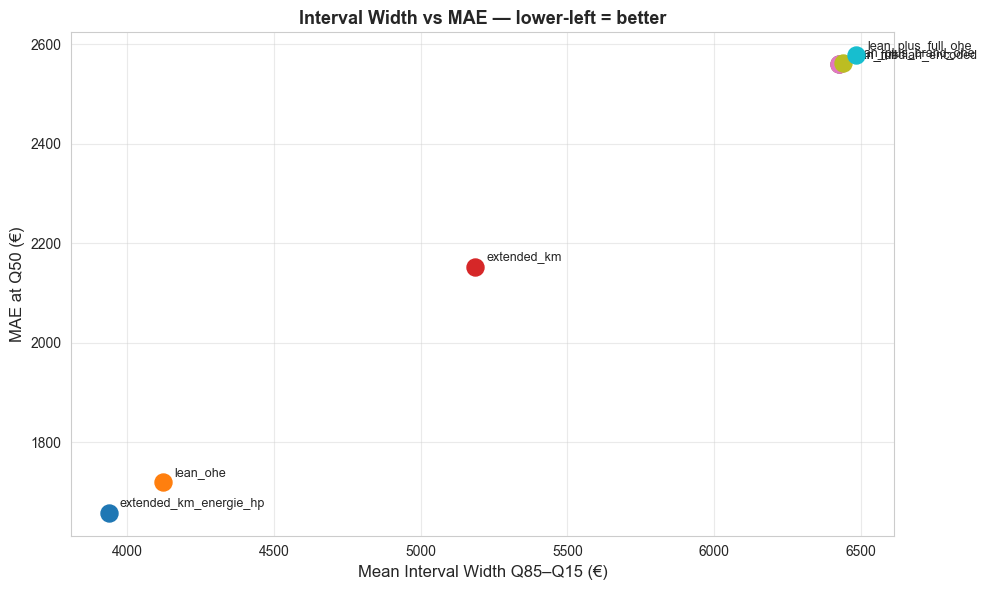

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.cm.tab10(np.linspace(0, 1, len(summary_df)))
for i, row in summary_df.iterrows():
    ax.scatter(row["mean_interval_width_eur"], row["MAE_q50_eur"],
               color=cmap[i - 1], s=150, zorder=5)
    ax.annotate(row["spec"], (row["mean_interval_width_eur"], row["MAE_q50_eur"]),
                xytext=(8, 4), textcoords="offset points", fontsize=9)
ax.set_xlabel("Mean Interval Width Q85–Q15 (€)", fontsize=12)
ax.set_ylabel("MAE at Q50 (€)", fontsize=12)
ax.set_title("Interval Width vs MAE — lower-left = better", fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "interval_width_vs_mae.png", dpi=120, bbox_inches="tight")
plt.show()

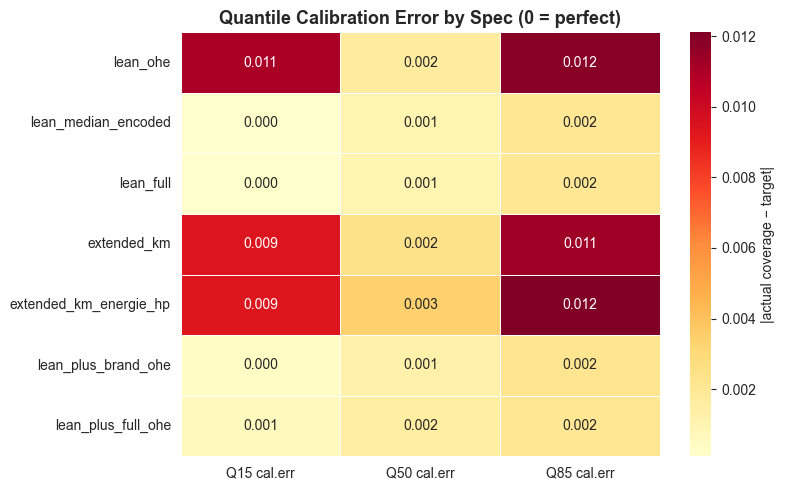

In [12]:
specs = list(results_store.keys())
calib_data = []
for s in specs:
    m = results_store[s]["q50"]["metrics"]
    calib_data.append({
        "Q15 cal.err": m.get("calib_calib_err_q15", np.nan),
        "Q50 cal.err": m.get("calib_calib_err_q50", np.nan),
        "Q85 cal.err": m.get("calib_calib_err_q85", np.nan),
    })
calib_df = pd.DataFrame(calib_data, index=specs)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(calib_df, annot=True, fmt=".3f", cmap="YlOrRd", linewidths=0.5, ax=ax,
            cbar_kws={"label": "|actual coverage − target|"})
ax.set_title("Quantile Calibration Error by Spec (0 = perfect)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "calibration_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

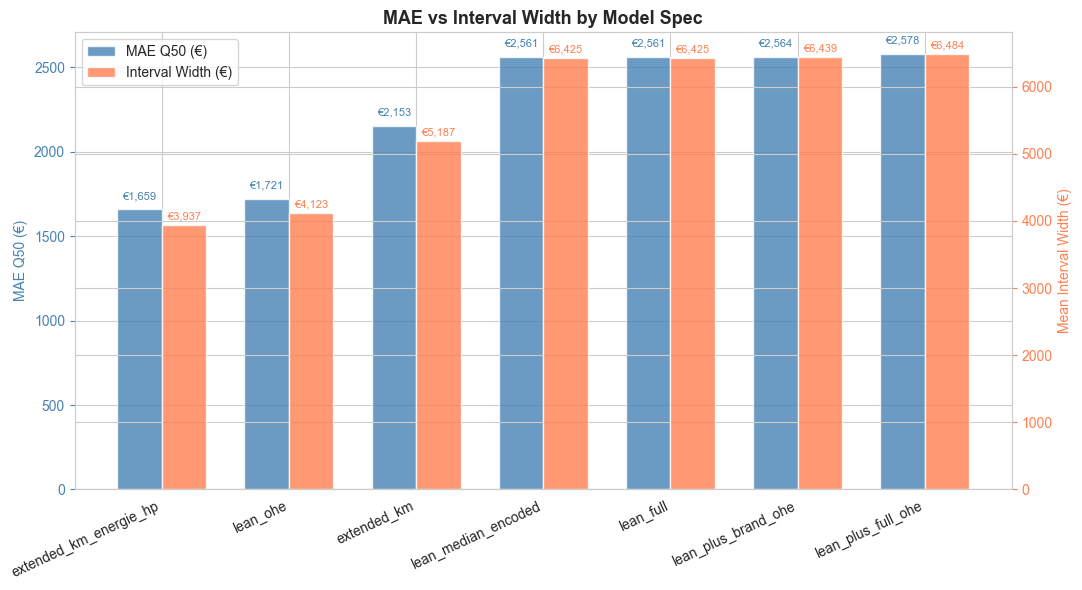

In [13]:
fig, ax1 = plt.subplots(figsize=(11, 6))
ax2 = ax1.twinx()
x = np.arange(len(summary_df))
w = 0.35
b1 = ax1.bar(x - w/2, summary_df["MAE_q50_eur"], w, label="MAE Q50 (€)", color="steelblue", alpha=0.8)
b2 = ax2.bar(x + w/2, summary_df["mean_interval_width_eur"], w, label="Interval Width (€)", color="coral", alpha=0.8)
ax1.set_xticks(x); ax1.set_xticklabels(summary_df["spec"], rotation=25, ha="right")
ax1.set_ylabel("MAE Q50 (€)", color="steelblue"); ax2.set_ylabel("Mean Interval Width (€)", color="coral")
ax1.tick_params(axis="y", colors="steelblue"); ax2.tick_params(axis="y", colors="coral")
for b in b1:
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+50, f"€{b.get_height():,.0f}",
             ha="center", va="bottom", fontsize=8, color="steelblue")
for b in b2:
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+50, f"€{b.get_height():,.0f}",
             ha="center", va="bottom", fontsize=8, color="coral")
ax1.set_title("MAE vs Interval Width by Model Spec", fontsize=13, fontweight="bold")
lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labs1+labs2, loc="upper left")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "mae_vs_interval_width_bar.png", dpi=120, bbox_inches="tight")
plt.show()

## 10. Per-Brand and Per-Model % Error Over Median Price

Metric: mean `|actual − pred| / brand_median_price × 100` per brand/model.  
This normalises by the typical price of that brand/model, making errors comparable across price segments.

In [ ]:
brand_pct_all = {}
model_pct_all = {}

for spec_name, spec_res in results_store.items():
    y_pred_eur = spec_res["q50"]["y_pred_eur"]
    brand_pct_all[spec_name] = compute_per_brand_pct_median_error(y_test_eur, y_pred_eur, brands_test)
    model_pct_all[spec_name] = compute_per_model_pct_median_error(y_test_eur, y_pred_eur, models_test)

# Top brands/models by test-set frequency
top20_brands = pd.Series(brands_test).value_counts().head(20).index.tolist()
top25_models = pd.Series(models_test).value_counts().head(25).index.tolist()

brand_heatmap_df = pd.DataFrame({s: brand_pct_all[s].reindex(top20_brands) for s in results_store}).T
model_heatmap_df = pd.DataFrame({s: model_pct_all[s].reindex(top25_models) for s in results_store}).T

print(f"Brand % error matrix: {brand_heatmap_df.shape}  |  Model % error matrix: {model_heatmap_df.shape}")

# ── Worst-10 brands per spec (ranked by % error over median) ─────────────────
print("\n── Worst-10 brands (% error over brand median price) per spec ──")
for spec_name in results_store:
    worst = brand_pct_all[spec_name].head(10)
    print(f"\n  {spec_name}:")
    for brand, pct in worst.items():
        print(f"    {brand:<25} {pct:>6.1f}%")

Brand MAE matrix: (7, 20)  |  Model MAE matrix: (7, 25)


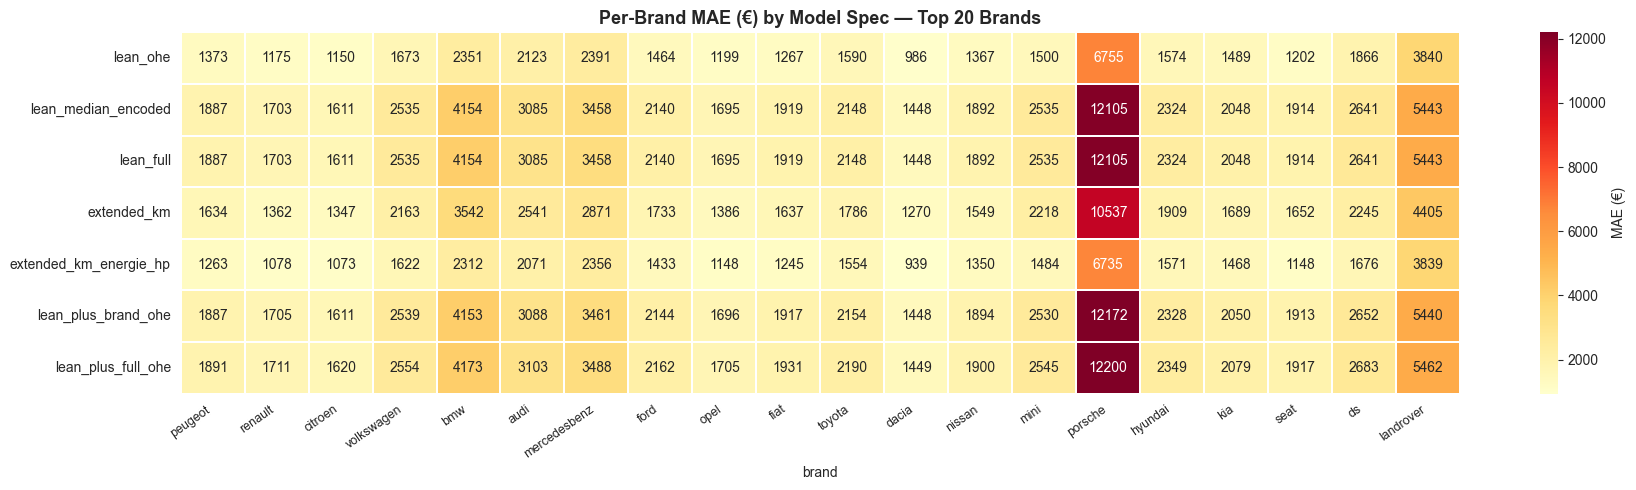

In [ ]:
fig, ax = plt.subplots(figsize=(18, 5))
sns.heatmap(brand_heatmap_df, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.3, ax=ax,
            cbar_kws={"label": "% error over brand median price"})
ax.set_title("Per-Brand % Error over Median Price — Top 20 Brands by Frequency", fontsize=13, fontweight="bold")
plt.xticks(rotation=35, ha="right", fontsize=9)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "per_brand_pct_error_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

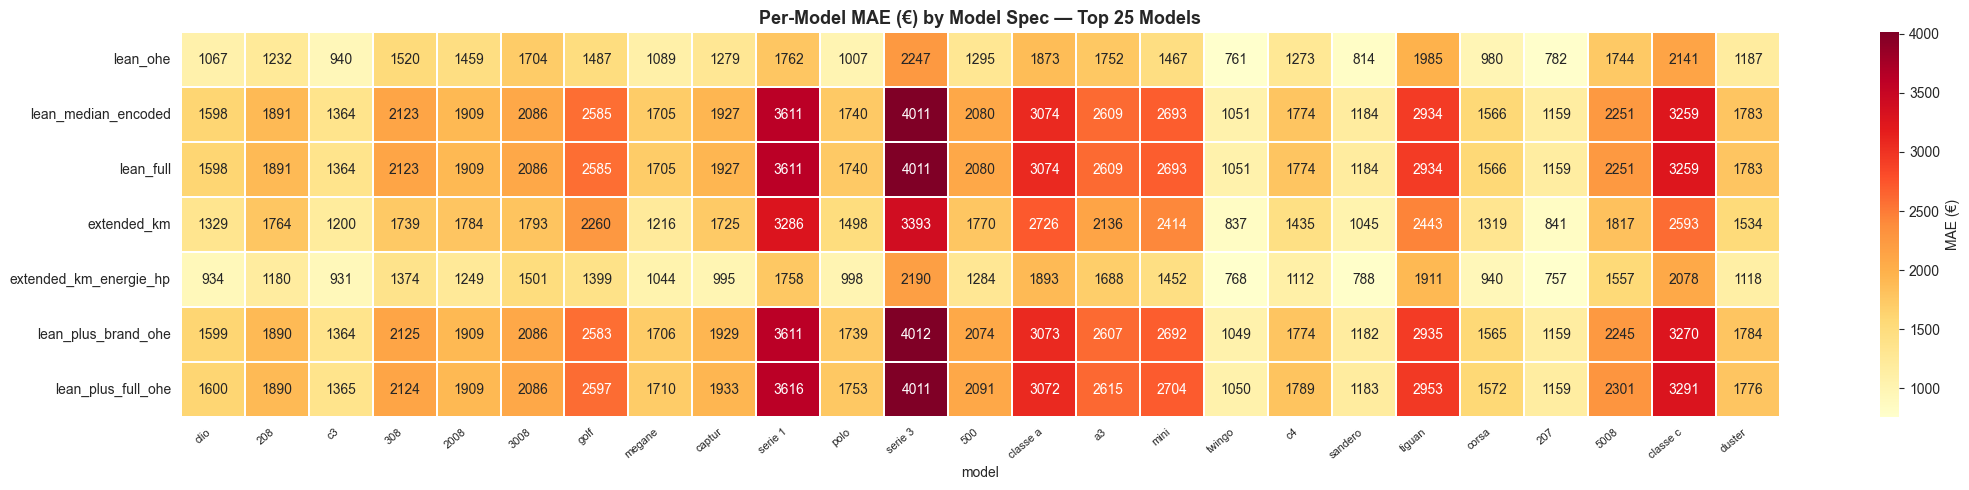

In [ ]:
fig, ax = plt.subplots(figsize=(22, 5))
sns.heatmap(model_heatmap_df, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.3, ax=ax,
            cbar_kws={"label": "% error over model median price"})
ax.set_title("Per-Model % Error over Median Price — Top 25 Models by Frequency", fontsize=13, fontweight="bold")
plt.xticks(rotation=40, ha="right", fontsize=8)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "per_model_pct_error_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

## 11. Log Summary Artifacts to MLflow

In [ ]:
summary_csv   = ARTIFACTS_DIR / "comparison_summary.csv"
brand_pct_csv = ARTIFACTS_DIR / "per_brand_pct_error.csv"
model_pct_csv = ARTIFACTS_DIR / "per_model_pct_error.csv"

summary_df.to_csv(summary_csv, index=False)
brand_heatmap_df.to_csv(brand_pct_csv)
model_heatmap_df.to_csv(model_pct_csv)

with mlflow.start_run(
    run_name="_summary_artifacts", experiment_id=experiment_id,
    tags={"type": "summary", "git_commit": GIT_COMMIT},
):
    for path in [summary_csv, brand_pct_csv, model_pct_csv]:
        mlflow.log_artifact(str(path))
    for png in ARTIFACTS_DIR.glob("*.png"):
        mlflow.log_artifact(str(png))
    best_spec = summary_df.iloc[0]["spec"]
    best_mae  = summary_df.iloc[0]["MAE_q50_eur"]
    mlflow.log_metrics({"best_mae_eur": best_mae})
    mlflow.set_tag("best_spec", best_spec)

print(f"✓ Summary artifacts logged")
print(f"  Best spec: {best_spec}  |  MAE: €{best_mae:,.0f}")
print(f"\nTo open MLflow UI:")
print(f"  mlflow ui --backend-store-uri file://{MLFLOW_DIR} --port 5001")

✓ Summary artifacts logged
  Best spec: extended_km_energie_hp  |  MAE: €1,659

To open MLflow UI:
  mlflow ui --backend-store-uri file:///Users/brunobrumbrum/car_price_prediction/mlruns --port 5001


## 12. Final Console Summary

In [18]:
print("=" * 72)
print("  EXPERIMENT SUMMARY — car_valuation_variable_addition_study")
print("=" * 72)
print(f"  {'Rank':<5} {'Spec':<30} {'MAE (€)':>12} {'MAPE%':>8} {'R²':>8} {'#Feats':>7}")
print("  " + "-" * 70)
for i, row in summary_df.iterrows():
    print(f"  {i:<5} {row['spec']:<30} €{row['MAE_q50_eur']:>9,.0f}"
          f"  {row['MAPE_q50_pct']:>7.2f}%"
          f"  {row['R2_q50']:>7.4f}"
          f"  {row['n_features']:>7.0f}")
print("=" * 72)
print(f"\n  Best spec: {best_spec}  (MAE = €{best_mae:,.0f})")
print(f"\n  Launch MLflow UI:")
print(f"    mlflow ui --backend-store-uri file://{MLFLOW_DIR} --port 5001")
print(f"    → http://localhost:5001")

  EXPERIMENT SUMMARY — car_valuation_variable_addition_study
  Rank  Spec                                MAE (€)    MAPE%       R²  #Feats
  ----------------------------------------------------------------------
  1     extended_km_energie_hp         €    1,659    13.04%   0.9647       61
  2     lean_ohe                       €    1,721    13.48%   0.9632     1061
  3     extended_km                    €    2,153    15.79%   0.9412       49
  4     lean_median_encoded            €    2,561    19.52%   0.9247       31
  5     lean_full                      €    2,561    19.52%   0.9247       31
  6     lean_plus_brand_ohe            €    2,564    19.52%   0.9242       73
  7     lean_plus_full_ohe             €    2,578    19.61%   0.9235     1046

  Best spec: extended_km_energie_hp  (MAE = €1,659)

  Launch MLflow UI:
    mlflow ui --backend-store-uri file:///Users/brunobrumbrum/car_price_prediction/mlruns --port 5001
    → http://localhost:5001
